<a href="https://www.kaggle.com/code/shivam240905/logistic-regression?scriptVersionId=346120984" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/dragonheir/logistic-regression/Social_Network_Ads.csv


In [2]:
from math import exp

In [3]:
# let take a dummy dataset

inputs = np.array([[2],
              [3],
              [5],
              [7]]) # shape -> (4, 1) and y also 4, 1
# X = np.array([[2, 3, 5, 6]])


X = np.c_[np.ones((inputs.shape[0], 1)), inputs]

print(X)

y = np.array([[1],
              [0],
              [0],
              [1]])

theta = theta = np.zeros((X.shape[1], 1))
print(theta.shape)

[[1. 2.]
 [1. 3.]
 [1. 5.]
 [1. 7.]]
(2, 1)


In [4]:
def prediction(X, theta):
    return 1 / (1 + np.exp(-np.dot(X, theta)))

In [5]:
test_pred = prediction(X, theta)
print(test_pred.shape)
print(test_pred)



(4, 1)
[[0.5]
 [0.5]
 [0.5]
 [0.5]]


In [6]:
def cost(X, y, theta):
    h = prediction(X, theta)
    n = len(X)
    return -np.mean(y*np.log(h) + (1 - y)*(np.log(1-h)))

In [7]:
test_cost = cost(X, y, theta)
print(test_cost)

0.6931471805599453


In [8]:
def batch_gradient(X, y, theta, lr, epochs):
    for i in range(epochs):
        h = prediction(X, theta)
        gradient = np.dot(X.T, y-h)
        theta = theta + lr * gradient

        # if (i%500==0):
        #     print("iteration", i)
        #     print("error: ", y-h)
    return theta

In [9]:
theta_new = batch_gradient(X, y, theta, 0.01, 5000)
# print(theta_new)

# print("final prediction: ", prediction(X, theta_new))
# print("cost: ", cost(X, y, theta_new))


In [10]:
inputs2 = np.array([
    [1],
    [2],
    [3],
    [4],
    [5],
    [6],
    [7],
    [8]
])

X2 = np.c_[np.ones((inputs2.shape[0], 1)), inputs2]

y2 = np.array([
    [0],
    [0],
    [0],
    [0],
    [1],
    [1],
    [1],
    [1]
])

theta_new_2 = batch_gradient(X2, y2, theta, 0.01, 5000)

In [11]:
print("theta:")
print(theta_new)

print("\npredictions:")
print(prediction(X, theta_new))

print("\nclasses:")
print((prediction(X, theta_new) >= 0.5).astype(int))

print("\ncost:")
print(cost(X, y, theta_new))

theta:
[[-0.58086155]
 [ 0.13677895]]

predictions:
[[0.42377302]
 [0.45747183]
 [0.52573554]
 [0.59305066]]

classes:
[[0]
 [0]
 [1]
 [1]]

cost:
0.6846345485234764


In [12]:
print("theta:")
print(theta_new_2)

print("\npredictions:")
print(prediction(X2, theta_new_2))

print("\nclasses:")
print((prediction(X2, theta_new_2) >= 0.5).astype(int))

print("\ncost:")
print(cost(X2, y2, theta_new_2))

theta:
[[-10.02645203]
 [  2.26709178]]

predictions:
[[4.26547473e-04]
 [4.10159849e-03]
 [3.82291946e-02]
 [2.77261791e-01]
 [7.87346921e-01]
 [9.72777158e-01]
 [9.97108806e-01]
 [9.99699656e-01]]

classes:
[[0]
 [0]
 [0]
 [0]
 [1]
 [1]
 [1]
 [1]]

cost:
0.07976329001470714


In [13]:
import matplotlib.pyplot as plt

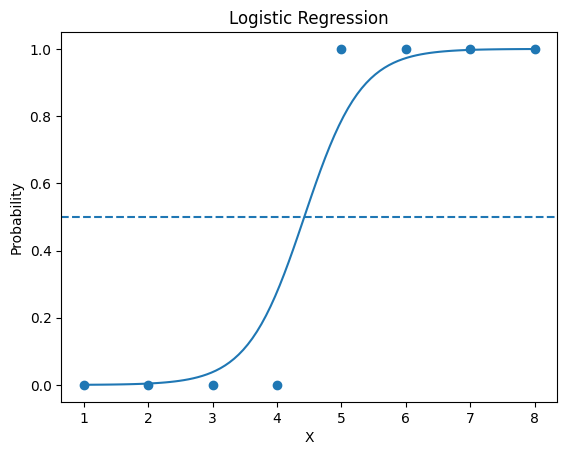

In [14]:
import matplotlib.pyplot as plt

# Create x values for a smooth sigmoid curve
x_values = np.linspace(1, 8, 100).reshape(-1, 1)


# Add bias column
x_plot = np.c_[np.ones((x_values.shape[0], 1)), x_values]

# Get predictions using learned theta
y_plot = prediction(x_plot, theta_new_2)

# Plot sigmoid curve
plt.plot(x_values, y_plot)

# Plot actual data points
plt.scatter(X2[:, 1], y2)

# Decision boundary at 0.5
plt.axhline(0.5, linestyle='--')

plt.xlabel("X")
plt.ylabel("Probability")
plt.title("Logistic Regression")

plt.show()

working on real ds


In [15]:
df = pd.read_csv('/kaggle/input/datasets/dragonheir/logistic-regression/Social_Network_Ads.csv')
df["Gender"] = df["Gender"].map({
    "Male": 1,
    "Female": 0
})
print(df)

      User ID  Gender  Age  EstimatedSalary  Purchased
0    15624510       1   19            19000          0
1    15810944       1   35            20000          0
2    15668575       0   26            43000          0
3    15603246       0   27            57000          0
4    15804002       1   19            76000          0
..        ...     ...  ...              ...        ...
395  15691863       0   46            41000          1
396  15706071       1   51            23000          1
397  15654296       0   50            20000          1
398  15755018       1   36            33000          0
399  15594041       0   49            36000          1

[400 rows x 5 columns]


In [16]:
#initializing dataset into np array
# shape should be (400, 3)

X_input = df[['Gender', 'Age', 'EstimatedSalary']].values
y_input = df['Purchased'].values.reshape(-1, 1)

print(X_input.shape)
print(y_input.shape)

# print(y_input)

(400, 3)
(400, 1)


In [17]:
from sklearn.model_selection import train_test_split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X_input,
    y_input,
    test_size=0.3,
    random_state=42
    
)
# Scale features
mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

X_train = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test = np.c_[np.ones((X_test.shape[0], 1)), X_test]


theta3 = np.zeros((X_train.shape[1], 1))

print(X_train.shape)
print(X_test.shape)
print(theta3)
print(theta3.shape)

(280, 4)
(120, 4)
[[0.]
 [0.]
 [0.]
 [0.]]
(4, 1)


In [19]:
theta_opt = batch_gradient(X_train, y_train, theta3, 0.001, 2000)
print(theta_opt)

print(cost(X_train, y_train, theta_opt))

[[-1.15588289]
 [ 0.1400104 ]
 [ 2.03977223]
 [ 1.1302371 ]]
0.37198027551503


In [20]:
train_pred = prediction(X_train, theta_opt)
train_classes = (train_pred >= 0.5).astype(int)

print(train_classes[:20])
print(y_train[:20])

[[0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [1]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [1]
 [1]
 [1]]
[[0]
 [0]
 [1]
 [1]
 [1]
 [0]
 [0]
 [0]
 [0]
 [1]
 [1]
 [0]
 [1]
 [0]
 [0]
 [0]
 [1]
 [1]
 [0]
 [1]]


In [21]:
train_accuracy = np.mean(train_classes == y_train)

print("Training accuracy:", train_accuracy)

Training accuracy: 0.8214285714285714


In [22]:
test_pred = prediction(X_test, theta_opt)
test_classes = (test_pred >= 0.5).astype(int)

test_accuracy = np.mean(test_classes == y_test)

print("Test accuracy:", test_accuracy)

Test accuracy: 0.8583333333333333


In [23]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, test_classes)

print(cm)

[[71  2]
 [15 32]]
